# Price Elasticity of Liquor Demand by Category and County in Iowa
This notebook follows the full outline: data prep → EDA → baseline model → extended models → findings.

## 0. Imports

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)


---
## 1. Data Preparation

In [69]:
# ── Load raw data ──────────────────────────────────────────────────────────────
df = pd.read_csv('cleaned_iowa_liquor_sales_merged.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year

print('Raw shape:', df.shape)
df.head(3)

Raw shape: (12300456, 15)


,Date,County,Category Name,Item Description,Pack,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars),Volume Sold (Liters),Year,Population,Is_Holiday_Weekend,Month
0,2015-11-09,BLACK HAWK,DECANTERS & SPECIALTY PACKAGES,Forbidden Secret Coffee Pack,6,1500,$11.62,$17.43,6,$104.58,9.0000,2015,99636,0,11
1,2015-11-30,MUSCATINE,DECANTERS & SPECIALTY PACKAGES,Laphroaig w/ Whiskey Stones,12,750,$19.58,$29.37,4,$117.48,3.0000,2015,31045,0,11
2,2015-11-11,IDA,DECANTERS & SPECIALTY PACKAGES,Forbidden Secret Coffee Pack,6,1500,$11.62,$17.43,1,$17.43,1.5000,2015,5151,1,11


In [70]:
df['Sale (Dollars)'] = df['Sale (Dollars)'].str.replace('$', '', regex=False).astype(float)

# Keeps rows where the column is NOT NaN AND NOT 0
df = df[df['Volume Sold (Liters)'].notna() & (df['Volume Sold (Liters)'] != 0)]
df = df[df['Sale (Dollars)'].notna() & (df['Sale (Dollars)'] != 0)]

# ── Price per liter ────────────────────────────────────────────────────────────
df['Price_Per_Liter'] = df['Sale (Dollars)'] / (df['Volume Sold (Liters)'])

# Weekend flag (Saturday=5, Sunday=6)
df['is_weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)

# Sanity check
print(df['Price_Per_Liter'].describe())
print(f"\nWeekend transactions: {df['is_weekend'].mean()*100:.1f}% of rows")


count   12296248.0000
mean          32.8876
std           76.1072
min            0.0457
25%            9.0400
50%           15.0000
75%           25.8800
max        25200.0000
Name: Price_Per_Liter, dtype: float64

Weekend transactions: 0.8% of rows


In [71]:
# ── Aggregate to county × year × month × category ────────────────────────────
agg = (
    df.groupby(['County', 'Year', 'Month', 'Category Name'])
    .agg(
        Total_Liters   = ('Volume Sold (Liters)', 'sum'),
        Total_Bottles  = ('Bottles Sold', 'sum'),
        Total_Sales    = ('Sale (Dollars)', 'sum'),
        Avg_Price      = ('Price_Per_Liter', 'mean'),
        Population     = ('Population', 'first'),
        Is_Holiday     = ('Is_Holiday_Weekend', 'max'),
        Holiday_Days   = ('Is_Holiday_Weekend', 'sum'),
        Weekend_Count  = ('is_weekend', 'sum'),          # weekend transaction count
    )
    .reset_index()
)

# ── Demand = liters per adult 20+ ─────────────────────────────────────────────
agg['Demand'] = agg['Total_Liters'] / agg['Population']

# ── Log transforms ────────────────────────────────────────────────────────────
agg['log_demand'] = np.log(agg['Demand'].replace(0, np.nan))
agg['log_price']  = np.log(agg['Avg_Price'].replace(0, np.nan))
agg = agg.dropna(subset=['log_demand', 'log_price'])

print('Aggregated shape:', agg.shape)
agg.head(3)


Aggregated shape: (324410, 15)


,County,Year,Month,Category Name,Total_Liters,Total_Bottles,Total_Sales,Avg_Price,Population,Is_Holiday,Holiday_Days,Weekend_Count,Demand,log_demand,log_price
0,ADAIR,2012,1,100 PROOF VODKA,39.0000,36,253.3200,6.5038,5681,0,0,0,0.0069,-4.9813,1.8724
1,ADAIR,2012,1,AMERICAN ALCOHOL,3.7500,5,60.1500,16.0400,5681,0,0,0,0.0007,-7.3231,2.7751
2,ADAIR,2012,1,AMERICAN AMARETTO,10.5000,14,70.9800,6.7933,5681,0,0,0,0.0018,-6.2935,1.9159


---
## 2. Exploratory Data Analysis
### 2A. Price and demand distributions

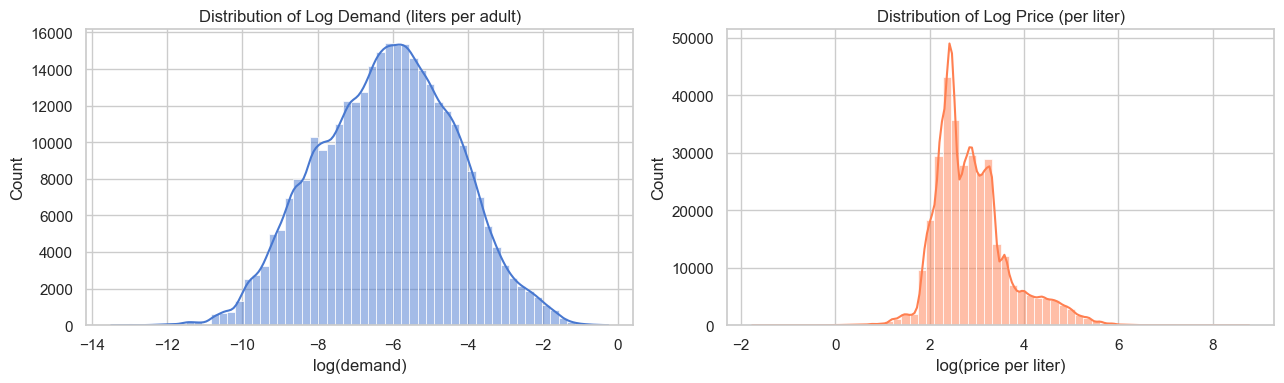

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(agg['log_demand'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Log Demand (liters per adult)')
axes[0].set_xlabel('log(demand)')

sns.histplot(agg['log_price'], bins=60, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Log Price (per liter)')
axes[1].set_xlabel('log(price per liter)')

plt.tight_layout()
plt.show()

### 2B. Raw log-log scatter (price vs demand)

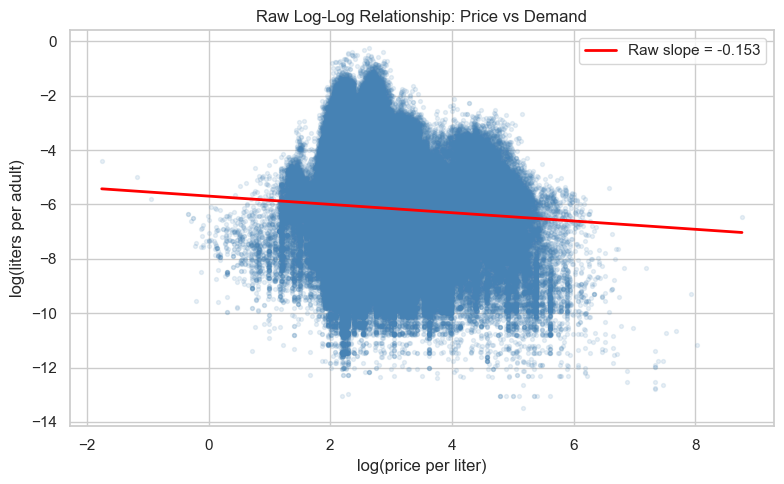

Raw (unadjusted) elasticity estimate: -0.153


In [73]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(agg['log_price'], agg['log_demand'], alpha=0.12, s=8, color='steelblue')

m, b = np.polyfit(agg['log_price'], agg['log_demand'], 1)
x_range = np.linspace(agg['log_price'].min(), agg['log_price'].max(), 100)
ax.plot(x_range, m * x_range + b, color='red', linewidth=2, label=f'Raw slope = {m:.3f}')

ax.set_xlabel('log(price per liter)')
ax.set_ylabel('log(liters per adult)')
ax.set_title('Raw Log-Log Relationship: Price vs Demand')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Raw (unadjusted) elasticity estimate: {m:.3f}')

### 2C. Seasonality — average demand by month

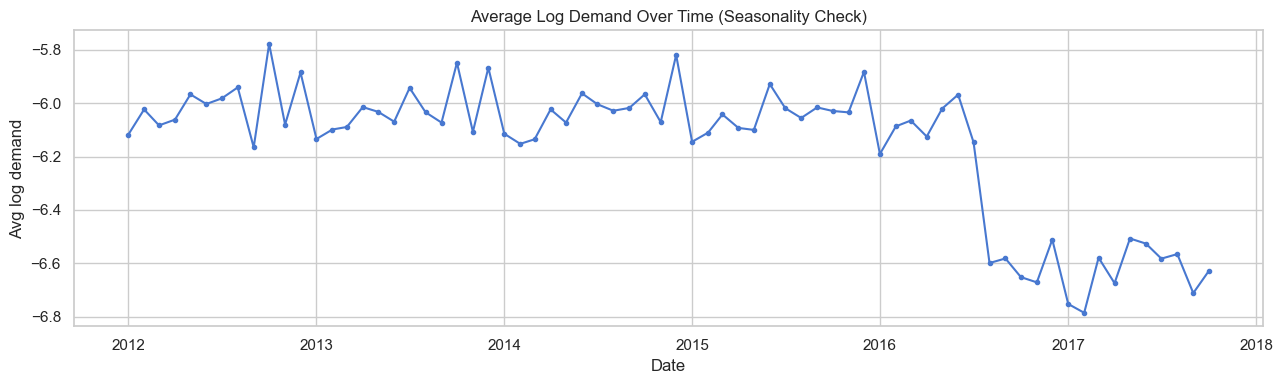

In [74]:
monthly = agg.groupby(['Year', 'Month'])['log_demand'].mean().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(day=1))
monthly = monthly.sort_values('Date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['Date'], monthly['log_demand'], marker='o', markersize=3, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Avg log demand')
ax.set_title('Average Log Demand Over Time (Seasonality Check)')
plt.tight_layout()
plt.show()

### 2D. Holiday vs non-holiday demand

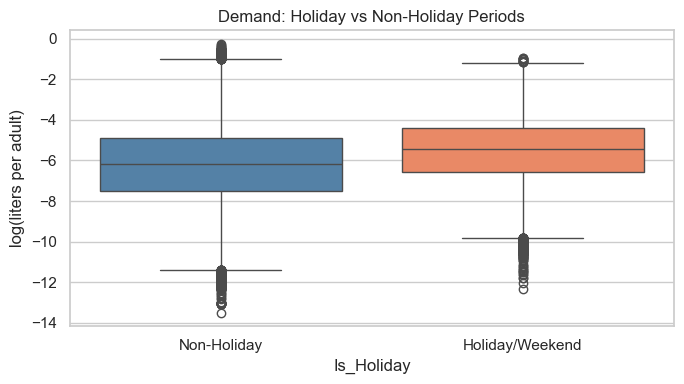

In [75]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=agg, x='Is_Holiday', y='log_demand', ax=ax, palette=['steelblue', 'coral'])
ax.set_xticklabels(['Non-Holiday', 'Holiday/Weekend'])
ax.set_ylabel('log(liters per adult)')
ax.set_title('Demand: Holiday vs Non-Holiday Periods')
plt.tight_layout()
plt.show()

### 2E. Top counties by average per-adult demand

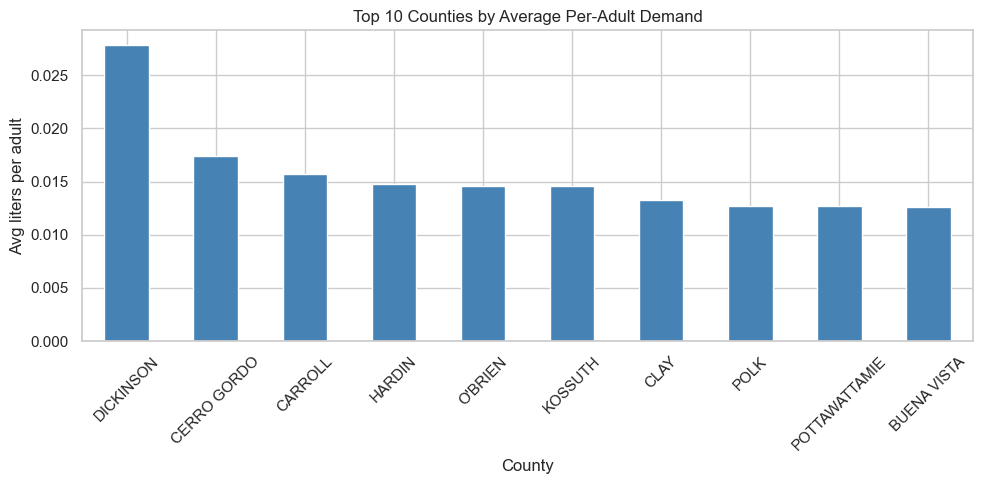

In [76]:
county_demand = agg.groupby('County')['Demand'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
county_demand.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Avg liters per adult')
ax.set_title('Top 10 Counties by Average Per-Adult Demand')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 2F. Demand distribution by category
Which categories drive the highest per-adult consumption?

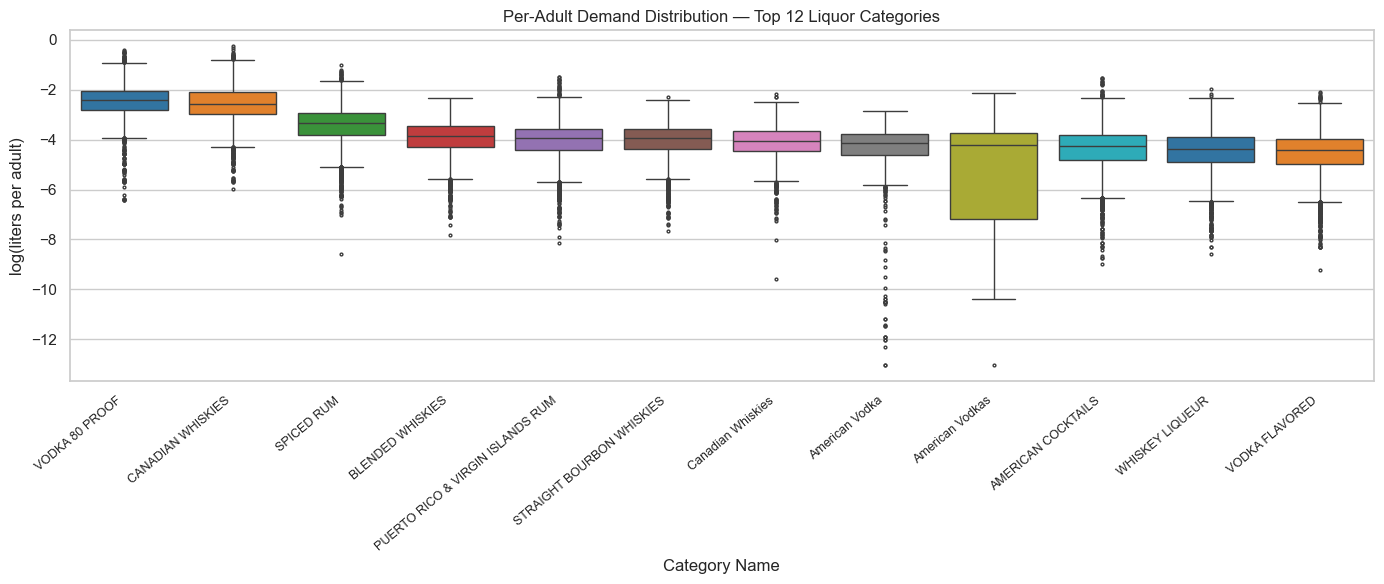

In [77]:
top_cats = (agg.groupby('Category Name')['log_demand'].median().sort_values(ascending=False).head(12).index.tolist())
cat_sub = agg[agg['Category Name'].isin(top_cats)].copy()
order = cat_sub.groupby('Category Name')['log_demand'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=cat_sub, x='Category Name', y='log_demand',
            order=order, palette='tab10', ax=ax, fliersize=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_ylabel('log(liters per adult)')
ax.set_title('Per-Adult Demand Distribution — Top 12 Liquor Categories')
plt.tight_layout()
plt.show()


### 2G. Seasonality heatmap — avg log demand by month × category
Reveals which categories have the strongest seasonal patterns.

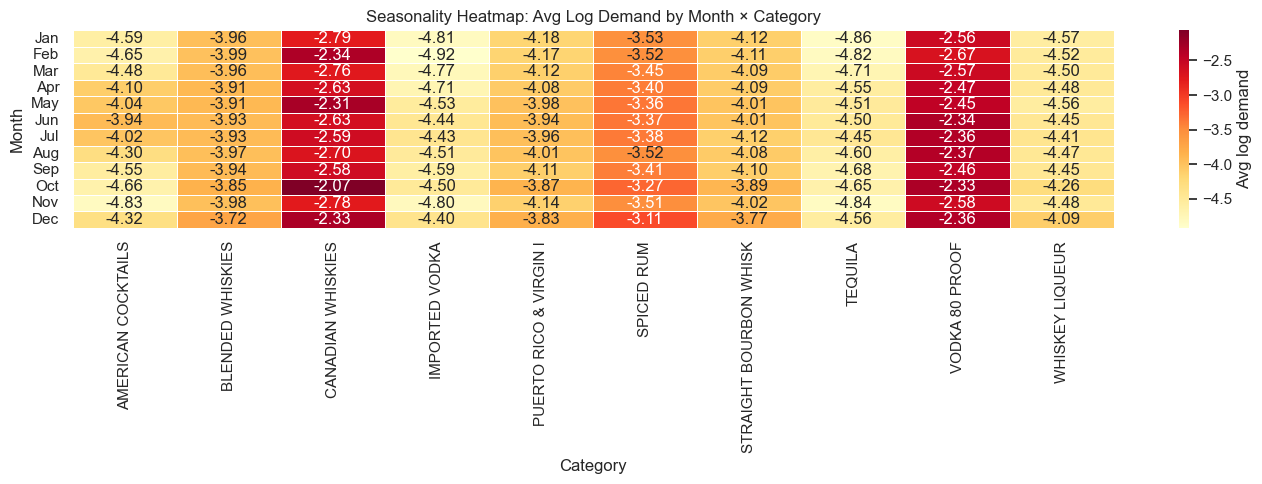

In [78]:
top10_cats = agg.groupby('Category Name')['Total_Liters'].sum().nlargest(10).index
heat_data = (agg[agg['Category Name'].isin(top10_cats)]
             .groupby(['Month', 'Category Name'])['log_demand']
             .mean().unstack('Category Name'))
heat_data.columns = [c[:22] for c in heat_data.columns]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat_data, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Avg log demand'})
ax.set_yticklabels(month_labels[:len(heat_data)], rotation=0)
ax.set_xlabel('Category')
ax.set_ylabel('Month')
ax.set_title('Seasonality Heatmap: Avg Log Demand by Month × Category')
plt.tight_layout()
plt.show()


### 2H. Price vs demand — faceted by top categories
Visualises the raw log-log slope separately for each major spirit type.

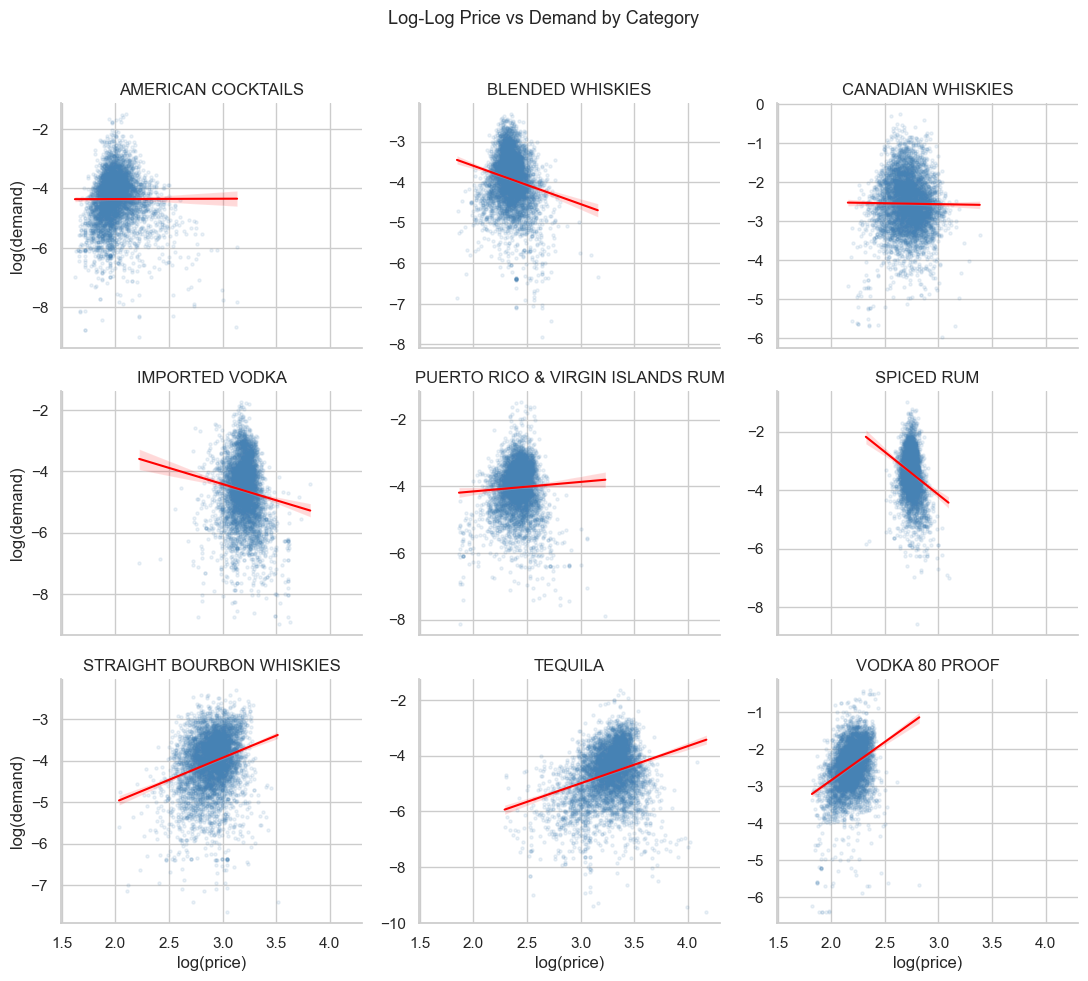

In [79]:
top9 = agg.groupby('Category Name')['Total_Liters'].sum().nlargest(9).index.tolist()
sub9 = agg[agg['Category Name'].isin(top9)].copy()

g = sns.FacetGrid(sub9, col='Category Name', col_wrap=3,
                  height=3.2, aspect=1.15, sharey=False)
g.map_dataframe(sns.regplot, x='log_price', y='log_demand',
                scatter_kws=dict(alpha=0.1, s=5, color='steelblue'),
                line_kws=dict(color='red', linewidth=1.5))
g.set_titles(col_template='{col_name}'[:28])
g.set_axis_labels('log(price)', 'log(demand)')
g.figure.suptitle('Log-Log Price vs Demand by Category', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### 2I. Weekend and holiday intensity vs demand

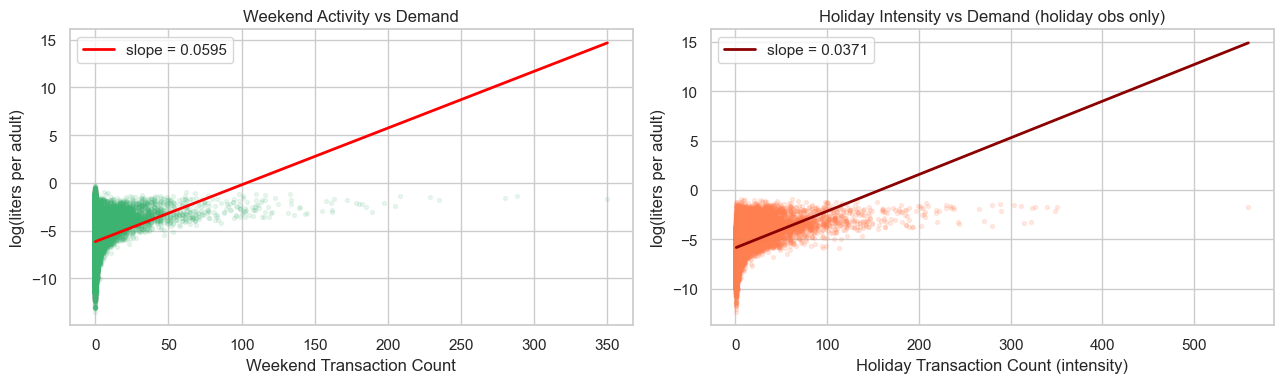

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Weekend count vs demand
axes[0].scatter(agg['Weekend_Count'], agg['log_demand'], alpha=0.1, s=8, color='mediumseagreen')
m_w, b_w = np.polyfit(agg['Weekend_Count'], agg['log_demand'], 1)
xw = np.linspace(agg['Weekend_Count'].min(), agg['Weekend_Count'].max(), 100)
axes[0].plot(xw, m_w*xw + b_w, color='red', linewidth=2, label=f'slope = {m_w:.4f}')
axes[0].set_xlabel('Weekend Transaction Count')
axes[0].set_ylabel('log(liters per adult)')
axes[0].set_title('Weekend Activity vs Demand')
axes[0].legend()

# Holiday intensity vs demand (holiday obs only)
hol = agg[agg['Is_Holiday'] == 1]
axes[1].scatter(hol['Holiday_Days'], hol['log_demand'], alpha=0.15, s=8, color='coral')
if len(hol) > 10:
    m_h, b_h = np.polyfit(hol['Holiday_Days'], hol['log_demand'], 1)
    xh = np.linspace(hol['Holiday_Days'].min(), hol['Holiday_Days'].max(), 100)
    axes[1].plot(xh, m_h*xh + b_h, color='darkred', linewidth=2, label=f'slope = {m_h:.4f}')
    axes[1].legend()
axes[1].set_xlabel('Holiday Transaction Count (intensity)')
axes[1].set_ylabel('log(liters per adult)')
axes[1].set_title('Holiday Intensity vs Demand (holiday obs only)')

plt.tight_layout()
plt.show()


---
## 3. Baseline Model — Log-Log Panel OLS with Fixed Effects
Model: log(demand) = α + β·log(price) + γ·Is_Holiday + county×category FE + time FE + ε

In [81]:
# ── Build panel indices ────────────────────────────────────────────────────────
panel = agg.copy()
# Period must be numeric or date-like for PanelOLS — use integer year-month
panel['Period'] = panel['Year'] * 12 + panel['Month']
panel['Entity'] = panel['County'] + '_' + panel['Category Name']
panel = panel.set_index(['Entity', 'Period'])

# ── Build exog: log_price + calendar controls + year/month dummies ────────────
X = panel[['log_price', 'Is_Holiday', 'Holiday_Days', 'Weekend_Count']].copy()
X['Year']  = panel['Year']
X['Month'] = panel['Month']
X = pd.get_dummies(X, columns=['Year', 'Month'], drop_first=True)
X = sm.add_constant(X).astype(float)

# ── Fit panel OLS with entity + time FE, clustered SE ────────────────────────
baseline = PanelOLS(
    dependent      = panel['log_demand'],
    exog           = X,
    entity_effects = True,
    time_effects   = True,
    drop_absorbed=True,
).fit(cov_type='clustered', cluster_entity=True)

print(baseline.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             log_demand   R-squared:                        0.0059
Estimator:                   PanelOLS   R-squared (Between):             -0.1000
No. Observations:              324410   R-squared (Within):               0.0032
Date:                Sun, Apr 12 2026   R-squared (Overall):              0.0074
Time:                        23:09:48   Log-likelihood                -3.196e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      461.18
Entities:                       11234   P-value                           0.0000
Avg Obs:                       28.878   Distribution:                F(4,313103)
Min Obs:                       1.0000                                           
Max Obs:                       56.000   F-statistic (robust):             154.81
                            

In [82]:
beta     = baseline.params['log_price']
ci       = baseline.conf_int().loc['log_price']
gamma    = baseline.params['Is_Holiday']
delta_wk = baseline.params['Weekend_Count']

print('=' * 60)
print(f'  Price Elasticity (β):      {beta:.4f}')
print(f'  95% CI:                    [{ci["lower"]:.4f}, {ci["upper"]:.4f}]')
print(f'  10% price increase →       {beta*10:.2f}% change in demand')
print()
print(f'  Holiday Effect (γ):        {gamma:.4f}')
print(f'  Weekend Count Effect (δ):  {delta_wk:.4f}')
print('=' * 60)


  Price Elasticity (β):      -0.1570
  95% CI:                    [-0.1747, -0.1393]
  10% price increase →       -1.57% change in demand

  Holiday Effect (γ):        0.0814
  Weekend Count Effect (δ):  -0.0027


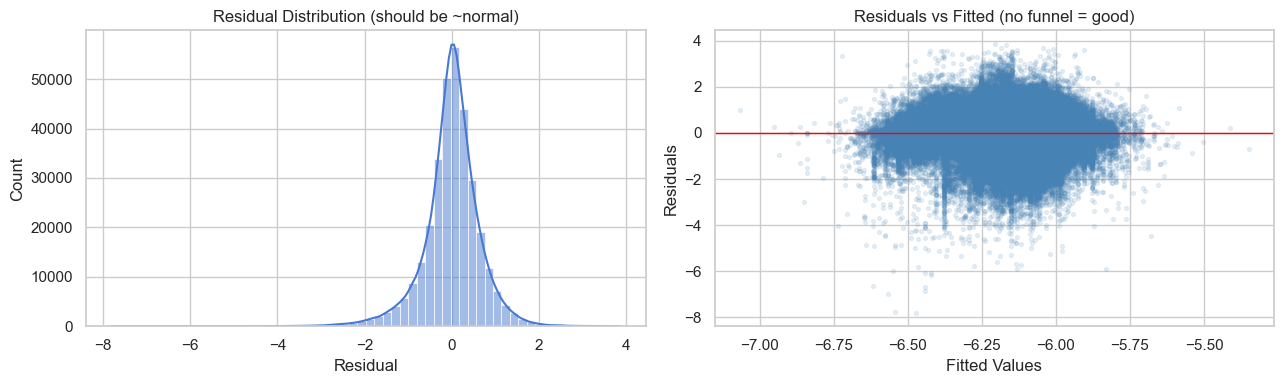

In [83]:
# ── Residual diagnostics ──────────────────────────────────────────────────────
resids  = baseline.resids
fitted  = baseline.fitted_values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(resids, bins=60, kde=True, ax=axes[0])
axes[0].set_title('Residual Distribution (should be ~normal)')
axes[0].set_xlabel('Residual')

axes[1].scatter(fitted, resids, alpha=0.12, s=8, color='steelblue')
axes[1].axhline(0, color='red', linewidth=1)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted (no funnel = good)')

plt.tight_layout()
plt.show()

---
## 4. Extended Models
### Model 1 — Category-Specific Elasticity

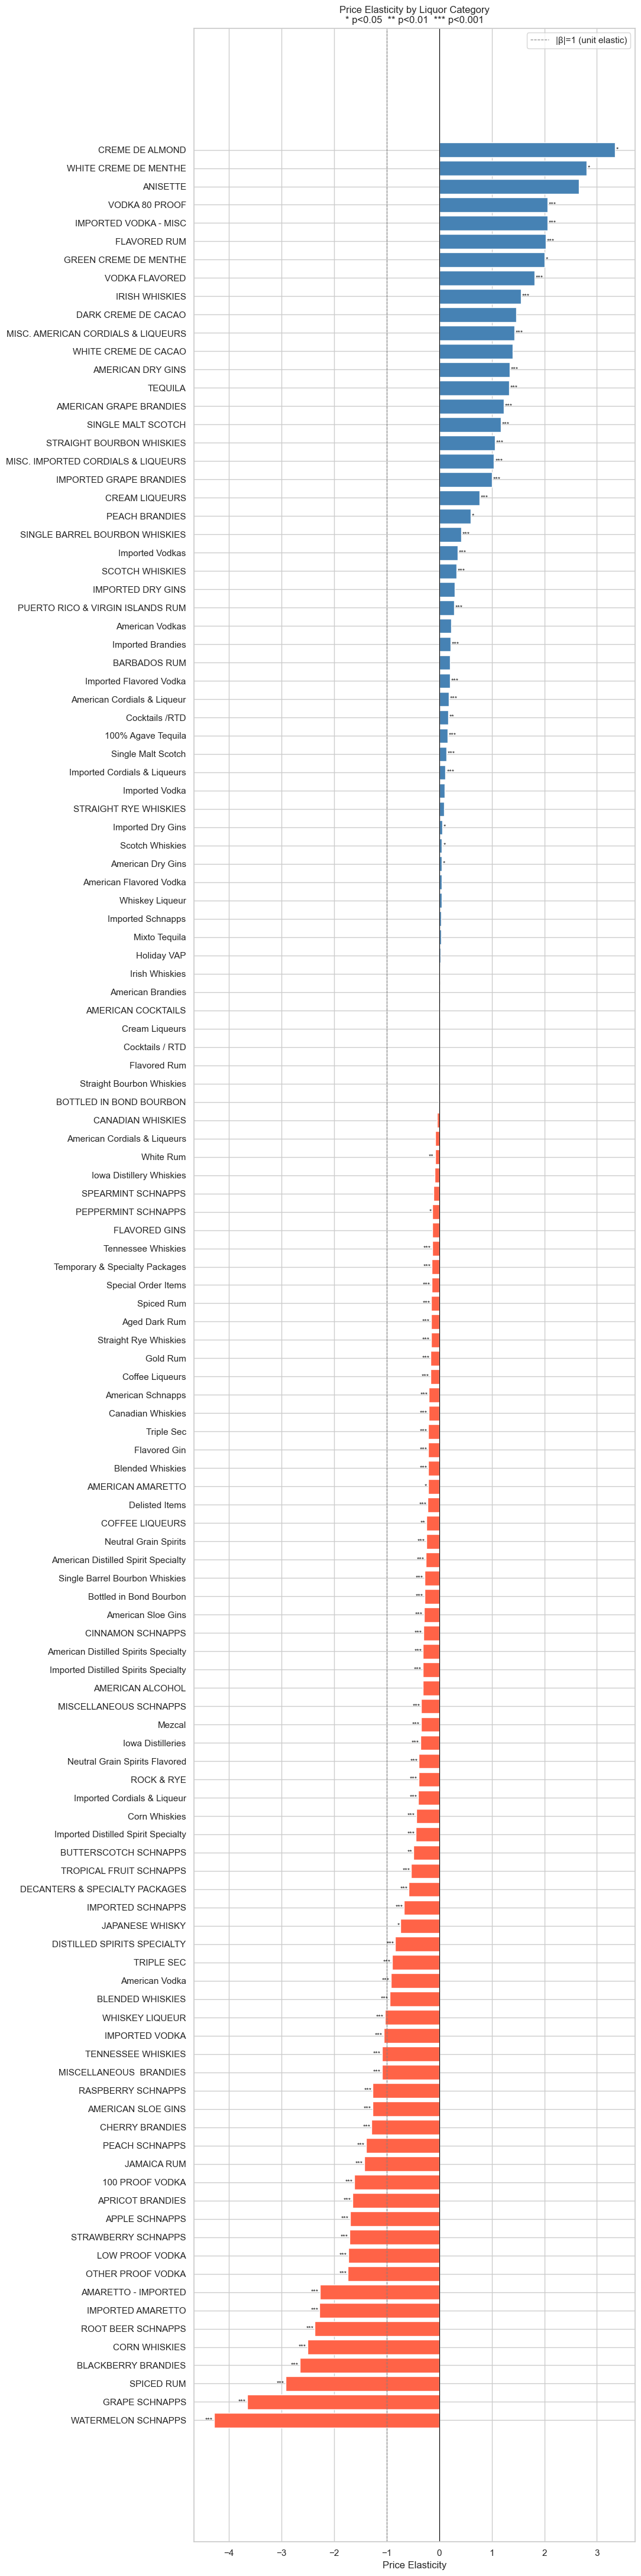


Top 5 most price-sensitive categories:
           Category  Elasticity  p_value     R2    N
WATERMELON SCHNAPPS     -4.2828   0.0000 0.0420 4083
     GRAPE SCHNAPPS     -3.6568   0.0000 0.0253 3347
         SPICED RUM     -2.9204   0.0000 0.0454 5529
BLACKBERRY BRANDIES     -2.6555   0.0000 0.0502 5242
      CORN WHISKIES     -2.5040   0.0000 0.2811  148


In [84]:
cat_elas = []
for cat, grp in agg.groupby('Category Name'):
    grp = grp.dropna(subset=['log_price', 'log_demand'])
    if len(grp) < 30:
        continue
    X_c = sm.add_constant(grp['log_price'])
    res = sm.OLS(grp['log_demand'], X_c).fit()
    cat_elas.append({
        'Category':   cat,
        'Elasticity': res.params['log_price'],
        'p_value':    res.pvalues['log_price'],
        'R2':         res.rsquared,
        'N':          len(grp),
    })

cat_df = pd.DataFrame(cat_elas).sort_values('Elasticity')

fig, ax = plt.subplots(figsize=(11, max(4, len(cat_df) * 0.35)))
colors = ['tomato' if e < 0 else 'steelblue' for e in cat_df['Elasticity']]
ax.barh(cat_df['Category'], cat_df['Elasticity'], color=colors)
for i, (_, row) in enumerate(cat_df.iterrows()):
    star = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else ''))
    offset = 0.02 if row['Elasticity'] >= 0 else -0.02
    ax.text(row['Elasticity'] + offset, i, star, va='center', fontsize=8,
            ha='left' if row['Elasticity'] >= 0 else 'right')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-1, color='gray', linewidth=0.8, linestyle='--', label='|β|=1 (unit elastic)')
ax.set_xlabel('Price Elasticity')
ax.set_title('Price Elasticity by Liquor Category\n* p<0.05  ** p<0.01  *** p<0.001')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 most price-sensitive categories:')
print(cat_df.head(5)[['Category','Elasticity','p_value','R2','N']].to_string(index=False))


### Model 2 — County-Level Price Sensitivity

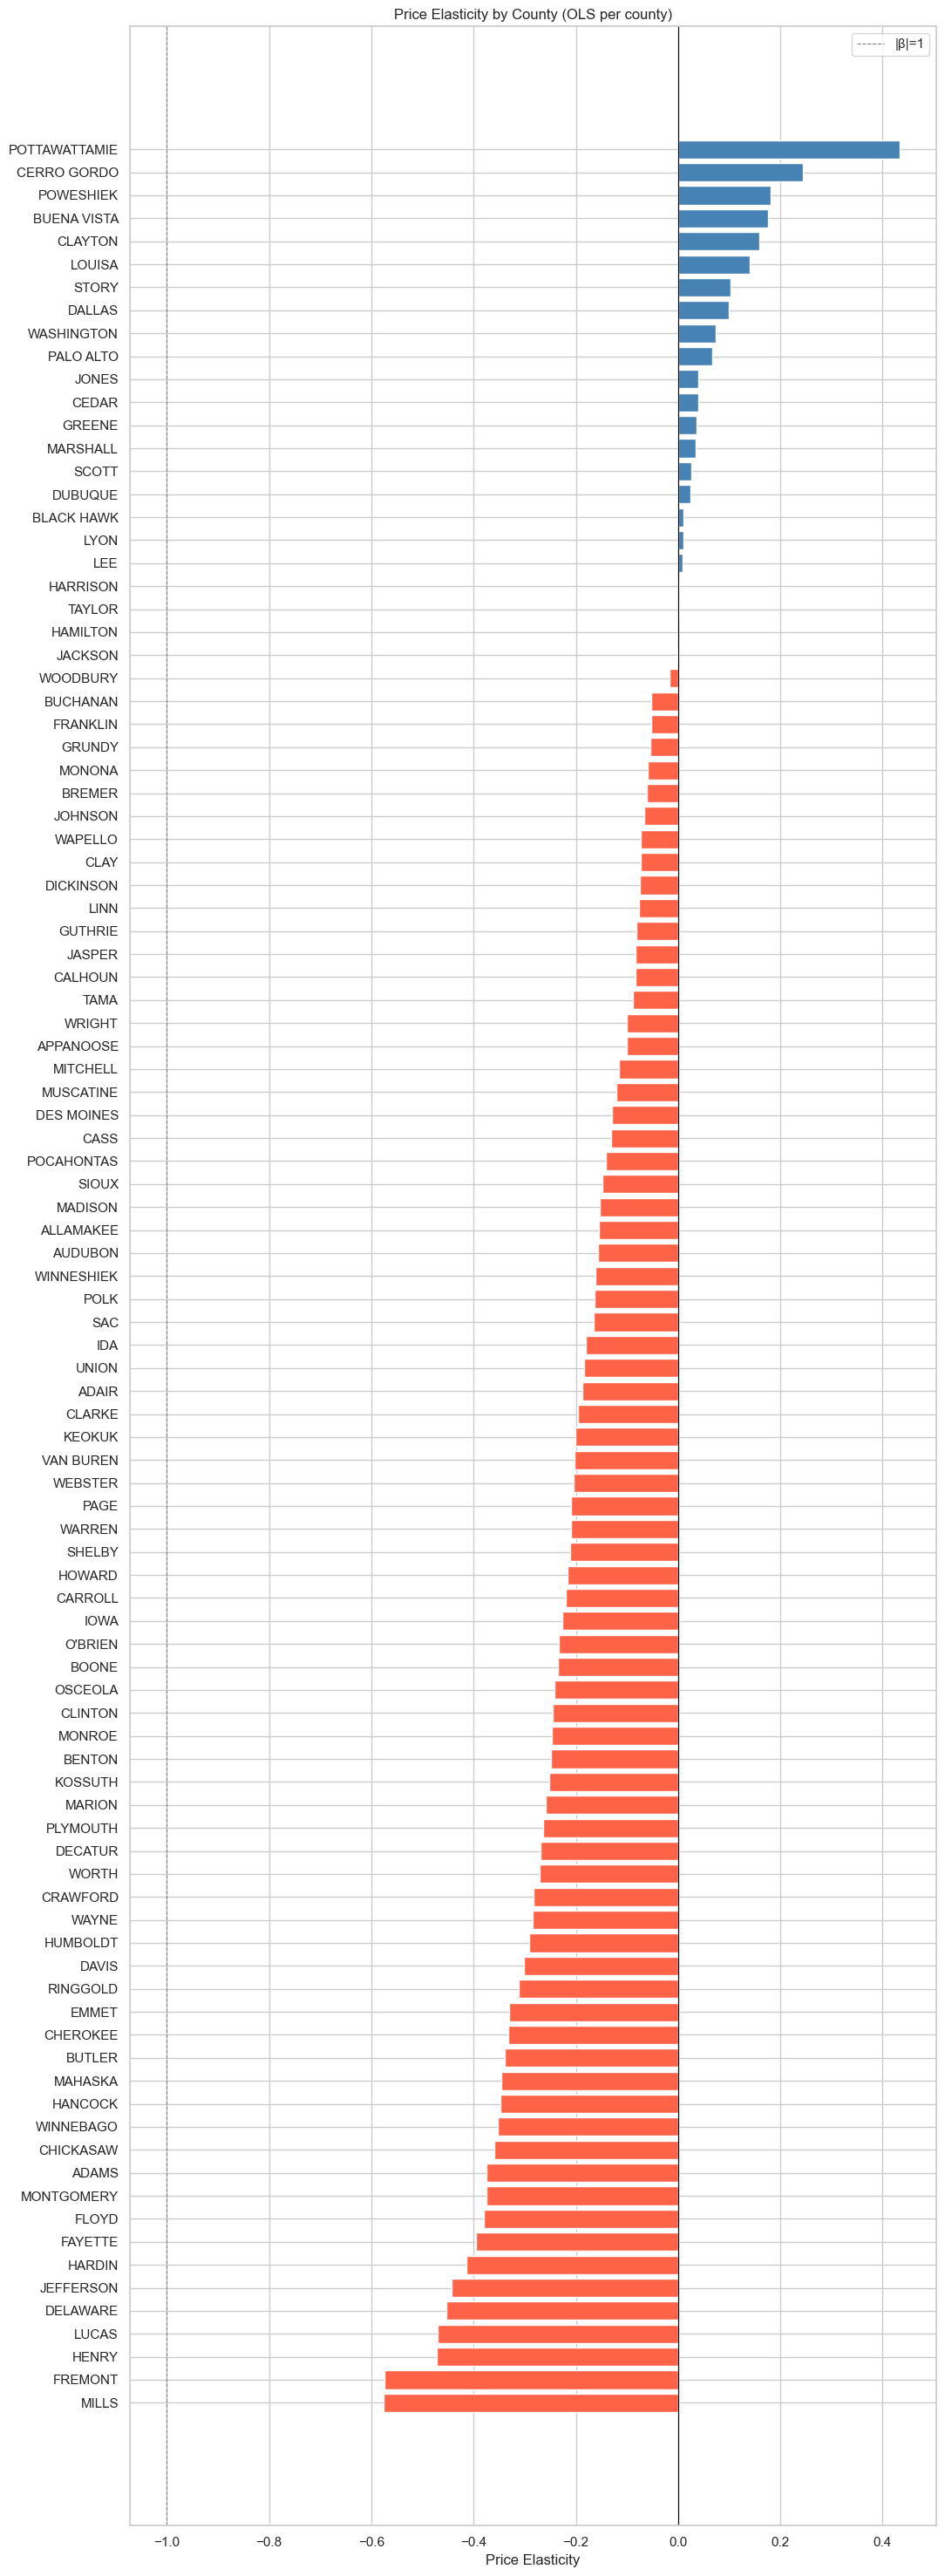


Most price-sensitive counties:
  County  Elasticity  p_value     R2    N
   MILLS     -0.5763   0.0000 0.0968 2422
 FREMONT     -0.5738   0.0000 0.3220  517
   HENRY     -0.4724   0.0000 0.0696 3214
   LUCAS     -0.4694   0.0000 0.0659 2997
DELAWARE     -0.4531   0.0000 0.0607 3133


In [85]:
county_elas = []
for county, grp in agg.groupby('County'):
    grp = grp.dropna(subset=['log_price', 'log_demand'])
    if len(grp) < 30:
        continue
    X_c = sm.add_constant(grp['log_price'])
    res = sm.OLS(grp['log_demand'], X_c).fit()
    county_elas.append({
        'County':     county,
        'Elasticity': res.params['log_price'],
        'p_value':    res.pvalues['log_price'],
        'R2':         res.rsquared,
        'N':          len(grp),
    })

county_df = pd.DataFrame(county_elas).sort_values('Elasticity')

fig, ax = plt.subplots(figsize=(11, max(4, len(county_df) * 0.3)))
colors = ['tomato' if e < 0 else 'steelblue' for e in county_df['Elasticity']]
ax.barh(county_df['County'], county_df['Elasticity'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-1, color='gray', linewidth=0.8, linestyle='--', label='|β|=1')
ax.set_xlabel('Price Elasticity')
ax.set_title('Price Elasticity by County (OLS per county)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nMost price-sensitive counties:')
print(county_df.head(5)[['County','Elasticity','p_value','R2','N']].to_string(index=False))


### Model 2B — Price Elasticity Heatmap: Top Counties × Top Categories
Identifies where pricing levers are strongest simultaneously.

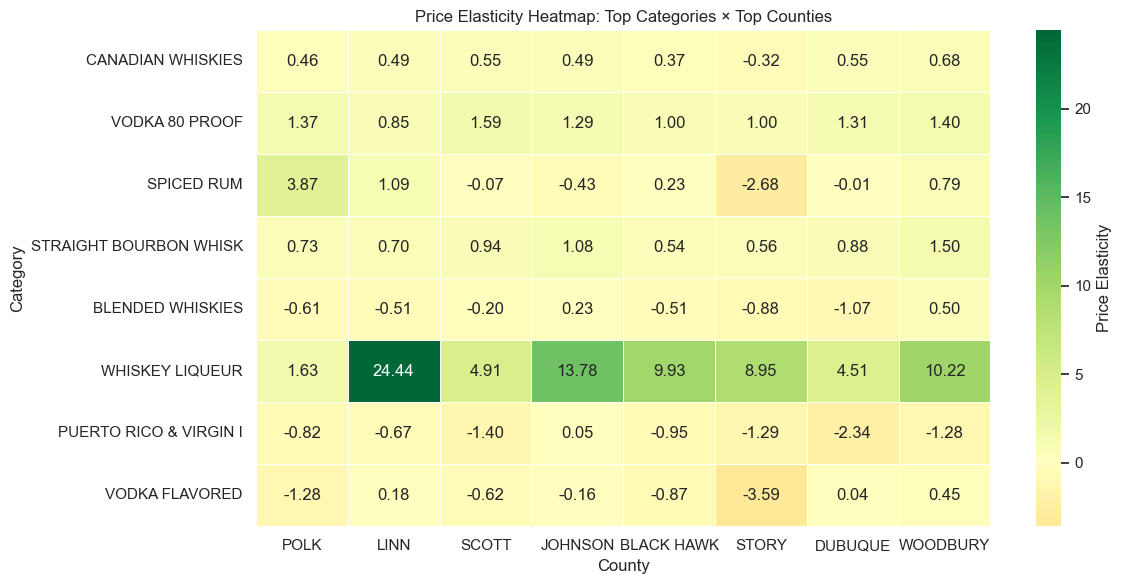

In [86]:
top8_counties = agg['County'].value_counts().head(8).index.tolist()
top8_cats     = agg['Category Name'].value_counts().head(8).index.tolist()

heat_elas = {}
for cat in top8_cats:
    row = {}
    for county in top8_counties:
        sub = agg[(agg['County'] == county) & (agg['Category Name'] == cat)]
        sub = sub.dropna(subset=['log_price', 'log_demand'])
        if len(sub) < 10:
            row[county] = np.nan
        else:
            res = sm.OLS(sub['log_demand'], sm.add_constant(sub['log_price'])).fit()
            row[county] = res.params['log_price']
    heat_elas[cat[:22]] = row

heat_df = pd.DataFrame(heat_elas).T

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat_df, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Price Elasticity'})
ax.set_title('Price Elasticity Heatmap: Top Categories × Top Counties')
ax.set_xlabel('County')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()


### Model 3 — Holiday × Price Interaction
Does price sensitivity change on holidays/weekends?

In [87]:
interact = agg.dropna(subset=['log_demand', 'log_price']).copy()
interact['price_x_holiday'] = interact['log_price'] * interact['Is_Holiday']
interact['price_x_weekend'] = interact['log_price'] * interact['Weekend_Count']

X_int = sm.add_constant(interact[[
    'log_price', 'Is_Holiday', 'price_x_holiday',
    'Weekend_Count', 'price_x_weekend'
]])
model_int = sm.OLS(interact['log_demand'], X_int).fit(cov_type='HC3')

print(model_int.summary2().tables[1])

int_hol = model_int.params['price_x_holiday']
int_wkd = model_int.params['price_x_weekend']
print(f'\nHoliday × Price:  {int_hol:.4f}  → consumers {"LESS" if int_hol > 0 else "MORE"} price sensitive on holidays')
print(f'Weekend × Price:  {int_wkd:.4f}  → consumers {"LESS" if int_wkd > 0 else "MORE"} price sensitive on weekends')


                  Coef.  Std.Err.         z  P>|z|  [0.025  0.975]
const           -5.7798    0.0131 -441.3089 0.0000 -5.8054 -5.7541
log_price       -0.1470    0.0043  -34.2494 0.0000 -0.1554 -0.1386
Is_Holiday       0.8896    0.0432   20.5734 0.0000  0.8048  0.9743
price_x_holiday -0.1146    0.0133   -8.5962 0.0000 -0.1407 -0.0885
Weekend_Count    0.0456    0.0114    3.9987 0.0001  0.0232  0.0679
price_x_weekend  0.0001    0.0035    0.0351 0.9720 -0.0067  0.0069

Holiday × Price:  -0.1146  → consumers MORE price sensitive on holidays
Weekend × Price:  0.0001  → consumers LESS price sensitive on weekends


### Model 3B — Visualising marginal price sensitivity across weekend activity

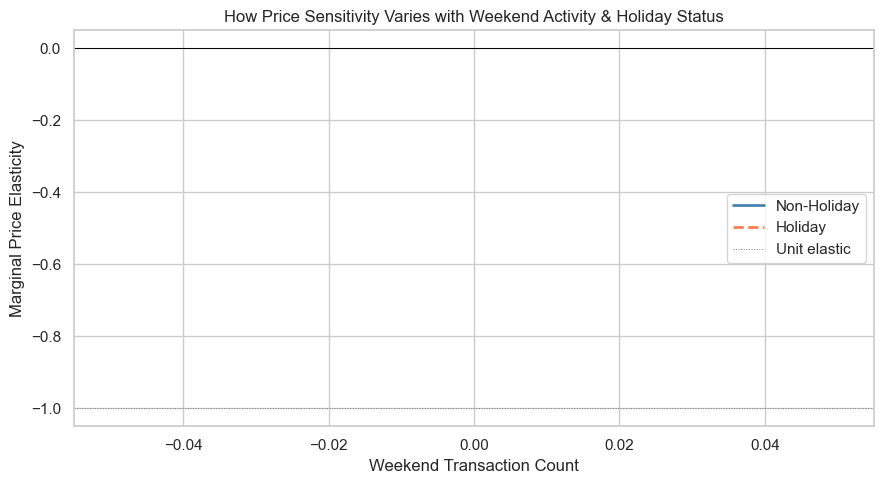

In [88]:
wk_range = np.linspace(0, agg['Weekend_Count'].quantile(0.95), 50)

elas_nonhol = model_int.params['log_price'] + model_int.params['price_x_weekend'] * wk_range
elas_hol    = (model_int.params['log_price'] + model_int.params['price_x_holiday']
               + model_int.params['price_x_weekend'] * wk_range)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wk_range, elas_nonhol, color='steelblue', linewidth=2, label='Non-Holiday')
ax.plot(wk_range, elas_hol,    color='coral', linewidth=2, linestyle='--', label='Holiday')
ax.axhline(0,  color='black', linewidth=0.7)
ax.axhline(-1, color='gray',  linewidth=0.7, linestyle=':', label='Unit elastic')
ax.set_xlabel('Weekend Transaction Count')
ax.set_ylabel('Marginal Price Elasticity')
ax.set_title('How Price Sensitivity Varies with Weekend Activity & Holiday Status')
ax.legend()
plt.tight_layout()
plt.show()


### Model 4 — Dynamic Extension (Lagged Demand)

In [89]:
dyn = agg.sort_values(['County', 'Category Name', 'Year', 'Month']).copy()
dyn['lag_log_demand'] = dyn.groupby(['County', 'Category Name'])['log_demand'].shift(1)
dyn = dyn.dropna(subset=['log_demand', 'log_price', 'lag_log_demand'])

X_dyn = sm.add_constant(dyn[['log_price', 'Is_Holiday', 'Weekend_Count', 'lag_log_demand']])
model_dyn = sm.OLS(dyn['log_demand'], X_dyn).fit(cov_type='HC3')

print(model_dyn.summary2().tables[1])
lag_coef = model_dyn.params['lag_log_demand']
print(f'\nLagged demand coefficient: {lag_coef:.4f}')
print(f'→ Demand shows {"strong" if lag_coef > 0.3 else "moderate"} persistence month to month')


                 Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const          -0.6995    0.0077 -90.6135 0.0000 -0.7146 -0.6843
log_price      -0.0183    0.0021  -8.8645 0.0000 -0.0224 -0.0143
Is_Holiday      0.0932    0.0047  19.7069 0.0000  0.0839  0.1024
Weekend_Count   0.0096    0.0006  16.8575 0.0000  0.0085  0.0107
lag_log_demand  0.8774    0.0009 958.3988 0.0000  0.8756  0.8792

Lagged demand coefficient: 0.8774
→ Demand shows strong persistence month to month


### Model 5 — Interaction-Based Category Elasticity (Single Model)
More statistically rigorous than separate per-category regressions: uses price × category dummies in one model, enabling formal comparison via F-test.

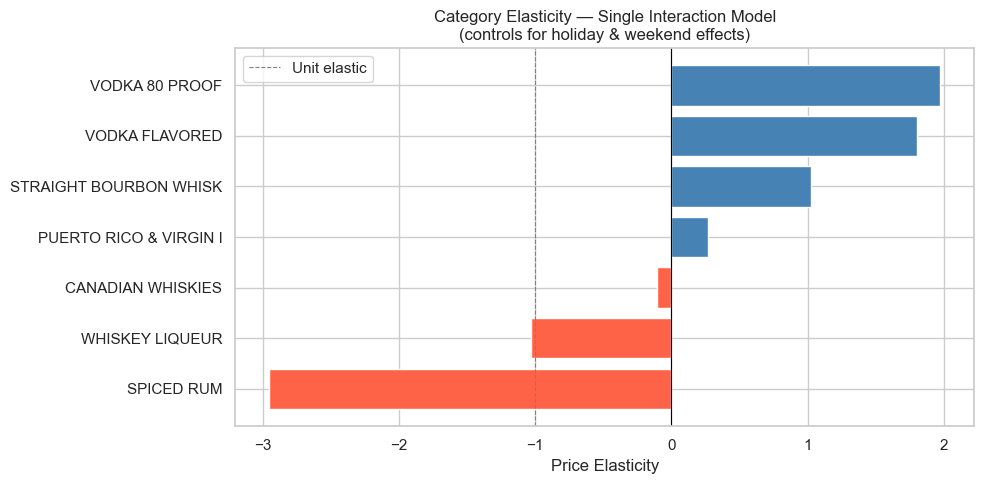

Model R²: 0.5343   Adj. R²: 0.5342


In [90]:
top8c = agg['Category Name'].value_counts().head(8).index.tolist()
m5_data = agg[agg['Category Name'].isin(top8c)].copy()
m5_data['cat_code'] = m5_data['Category Name'].apply(lambda x: x[:22])

cat_dummies = pd.get_dummies(m5_data['cat_code'], prefix='cat', drop_first=True)
price_x_cat = cat_dummies.multiply(m5_data['log_price'].values, axis=0)
price_x_cat.columns = [c + '_x_price' for c in price_x_cat.columns]

X_m5 = sm.add_constant(pd.concat([
    m5_data[['log_price', 'Is_Holiday', 'Weekend_Count']].reset_index(drop=True),
    cat_dummies.reset_index(drop=True),
    price_x_cat.reset_index(drop=True),
], axis=1)).astype(float)

y_m5 = m5_data['log_demand'].reset_index(drop=True)
model5 = sm.OLS(y_m5, X_m5).fit(cov_type='HC3')

# Extract implied elasticity per category
base_elas = model5.params['log_price']
base_cat  = m5_data['cat_code'].value_counts().index[0]
cat_elas5 = {base_cat: base_elas}
for col in [c for c in model5.params.index if c.endswith('_x_price')]:
    cat_name = col.replace('_x_price', '').replace('cat_', '')
    cat_elas5[cat_name] = base_elas + model5.params[col]

elas5_df = pd.DataFrame(list(cat_elas5.items()), columns=['Category','Elasticity']).sort_values('Elasticity')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if e < 0 else 'steelblue' for e in elas5_df['Elasticity']]
ax.barh(elas5_df['Category'], elas5_df['Elasticity'], color=colors)
ax.axvline(0,  color='black', linewidth=0.8)
ax.axvline(-1, color='gray',  linewidth=0.8, linestyle='--', label='Unit elastic')
ax.set_xlabel('Price Elasticity')
ax.set_title('Category Elasticity — Single Interaction Model\n(controls for holiday & weekend effects)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Model R²: {model5.rsquared:.4f}   Adj. R²: {model5.rsquared_adj:.4f}')


---
## 5. Model Comparison
Compares Adj. R², AIC, and BIC across all estimated OLS models on a common sample.

In [91]:
# Build common sample (requires lag)
cmp = agg.sort_values(['County', 'Category Name', 'Year', 'Month']).copy()
cmp['lag_log_demand'] = cmp.groupby(['County', 'Category Name'])['log_demand'].shift(1)
cmp = cmp.dropna(subset=['log_demand', 'log_price', 'lag_log_demand'])
cmp['price_x_holiday'] = cmp['log_price'] * cmp['Is_Holiday']
cmp['price_x_weekend'] = cmp['log_price'] * cmp['Weekend_Count']
y_cmp = cmp['log_demand']

def fit_cmp(cols, label):
    res = sm.OLS(y_cmp, sm.add_constant(cmp[cols].astype(float))).fit()
    return {'Model': label, 'R²': round(res.rsquared,4),
            'Adj. R²': round(res.rsquared_adj,4),
            'AIC': round(res.aic,1), 'BIC': round(res.bic,1), 'N': int(res.nobs)}

comp_df = pd.DataFrame([
    fit_cmp(['log_price'],
            'M0: Price only'),
    fit_cmp(['log_price', 'Is_Holiday'],
            'M1: + Holiday'),
    fit_cmp(['log_price', 'Is_Holiday', 'Weekend_Count'],
            'M2: + Weekend'),
    fit_cmp(['log_price', 'Is_Holiday', 'Weekend_Count', 'price_x_holiday', 'price_x_weekend'],
            'M3: + Interactions'),
    fit_cmp(['log_price', 'Is_Holiday', 'Weekend_Count', 'lag_log_demand'],
            'M4: + Lagged demand'),
])
print(comp_df.to_string(index=False))


              Model     R²  Adj. R²          AIC          BIC      N
     M0: Price only 0.0029   0.0029 1254657.8000 1254679.1000 313176
      M1: + Holiday 0.0154   0.0154 1250707.6000 1250739.5000 313176
      M2: + Weekend 0.0224   0.0224 1248496.8000 1248539.5000 313176
 M3: + Interactions 0.0226   0.0226 1248413.4000 1248477.3000 313176
M4: + Lagged demand 0.7799   0.7799  781553.4000  781606.7000 313176


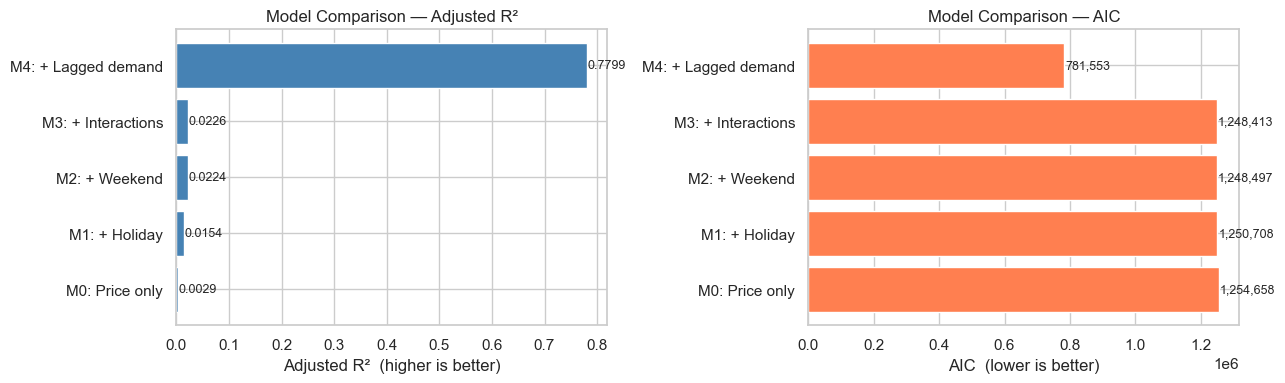

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(comp_df['Model'], comp_df['Adj. R²'], color='steelblue')
axes[0].set_xlabel('Adjusted R²  (higher is better)')
axes[0].set_title('Model Comparison — Adjusted R²')
for i, v in enumerate(comp_df['Adj. R²']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(comp_df['Model'], comp_df['AIC'], color='coral')
axes[1].set_xlabel('AIC  (lower is better)')
axes[1].set_title('Model Comparison — AIC')
for i, v in enumerate(comp_df['AIC']):
    axes[1].text(v + comp_df['AIC'].max()*0.003, i, f'{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


---
## 6. Holdout Validation
Train on 2012–2015, test on 2016–2017. Reports RMSE and residual distribution.


In [93]:
val = agg.sort_values(['County', 'Category Name', 'Year', 'Month']).copy()
val['lag_log_demand'] = val.groupby(['County', 'Category Name'])['log_demand'].shift(1)
val = val.dropna(subset=['log_demand', 'log_price', 'lag_log_demand'])

train = val[val['Year'] <= 2015]
test  = val[val['Year'] >= 2016]

feats = ['log_price', 'Is_Holiday', 'Weekend_Count', 'lag_log_demand']
X_tr = sm.add_constant(train[feats].astype(float))
X_te = sm.add_constant(test[feats].astype(float)).reindex(columns=X_tr.columns, fill_value=0)

model_val = sm.OLS(train['log_demand'], X_tr).fit()
y_pred    = model_val.predict(X_te)
y_true    = test['log_demand']

rmse_train = np.sqrt(mean_squared_error(train['log_demand'], model_val.fittedvalues))
rmse_test  = np.sqrt(mean_squared_error(y_true, y_pred))
r2_test    = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

print(f'Train years: 2012–2015  ({len(train):,} obs)')
print(f'Test  years: 2016–2017  ({len(test):,} obs)')
print(f'Train RMSE: {rmse_train:.4f}')
print(f'Test  RMSE: {rmse_test:.4f}')
print(f'R²  (test): {r2_test:.4f}')


Train years: 2012–2015  (228,815 obs)
Test  years: 2016–2017  (84,361 obs)
Train RMSE: 0.8410
Test  RMSE: 0.8483
R²  (test): 0.7510


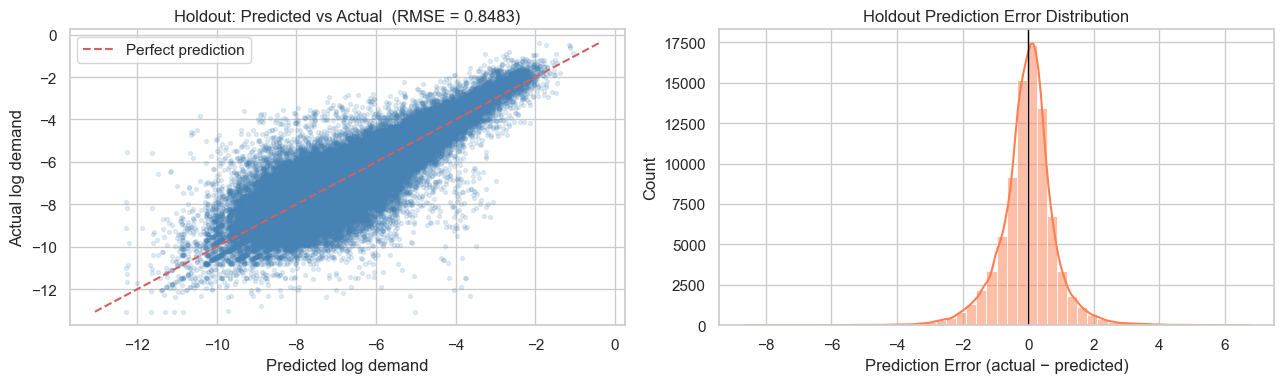

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Predicted vs Actual
axes[0].scatter(y_pred, y_true, alpha=0.15, s=8, color='steelblue')
mn = min(y_pred.min(), y_true.min())
mx = max(y_pred.max(), y_true.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Predicted log demand')
axes[0].set_ylabel('Actual log demand')
axes[0].set_title(f'Holdout: Predicted vs Actual  (RMSE = {rmse_test:.4f})')
axes[0].legend()

# Residual distribution
resid_test = y_true.values - y_pred.values
sns.histplot(resid_test, bins=50, kde=True, ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Prediction Error (actual − predicted)')
axes[1].set_title('Holdout Prediction Error Distribution')

plt.tight_layout()
plt.show()


---
## 7. Findings Summary


In [95]:
print('=' * 65)
print('  FINDINGS SUMMARY')
print('=' * 65)

beta = baseline.params['log_price']
elas_type = 'INELASTIC (|β| < 1)' if abs(beta) < 1 else 'ELASTIC (|β| > 1)'
print(f'\n1. Overall price elasticity:   {beta:.4f}  → Demand is {elas_type}')
print(f'   10% price increase →         {beta*10:.2f}% change in demand')

most_cat    = cat_df.iloc[0]
most_county = county_df.iloc[0]
print(f'\n2. Most price-sensitive category: {most_cat["Category"]}')
print(f'   Elasticity = {most_cat["Elasticity"]:.4f}  (p={most_cat["p_value"]:.4f}, R²={most_cat["R2"]:.4f})')

print(f'\n3. Most price-sensitive county:   {most_county["County"]}')
print(f'   Elasticity = {most_county["Elasticity"]:.4f}  (p={most_county["p_value"]:.4f})')

gamma    = baseline.params['Is_Holiday']
delta_wk = baseline.params['Weekend_Count']
print(f'\n4. Holiday effect (γ):           {gamma:.4f} log-unit shift in demand')
print(f'   Weekend count effect (δ):      {delta_wk:.4f} per additional weekend txn')
print(f'   Holiday × Price interaction:   {int_hol:.4f}  → {"less" if int_hol > 0 else "more"} price sensitive on holidays')
print(f'   Weekend × Price interaction:   {int_wkd:.4f}  → {"less" if int_wkd > 0 else "more"} price sensitive on weekends')

print(f'\n5. Lagged demand coefficient:    {lag_coef:.4f}')
print(f'   → {"Strong" if lag_coef > 0.3 else "Moderate"} month-to-month demand persistence')

best_m = comp_df.loc[comp_df['Adj. R²'].idxmax(), 'Model']
print(f'\n6. Best model (Adj. R²):         {best_m}')
print(f'   Holdout test RMSE:             {rmse_test:.4f}   R² (test): {r2_test:.4f}')

print('\n' + '=' * 65)
print('  MANAGERIAL RECOMMENDATIONS')
print('=' * 65)
print('  1. Category-specific pricing — elasticity varies significantly by spirit type')
print('  2. Geographic differentiation — target promotions to high-elasticity counties')
print('  3. Joint holiday planning — demand spikes but price sensitivity may shift')
print('  4. Use weekend transaction intensity as a real-time demand signal')
print('  5. Leverage demand persistence — prior month demand predicts current demand')
print('  6. Normalise by adult population for unbiased county-level comparisons')


  FINDINGS SUMMARY

1. Overall price elasticity:   -0.1570  → Demand is INELASTIC (|β| < 1)
   10% price increase →         -1.57% change in demand

2. Most price-sensitive category: WATERMELON SCHNAPPS
   Elasticity = -4.2828  (p=0.0000, R²=0.0420)

3. Most price-sensitive county:   MILLS
   Elasticity = -0.5763  (p=0.0000)

4. Holiday effect (γ):           0.0814 log-unit shift in demand
   Weekend count effect (δ):      -0.0027 per additional weekend txn
   Holiday × Price interaction:   -0.1146  → more price sensitive on holidays
   Weekend × Price interaction:   0.0001  → less price sensitive on weekends

5. Lagged demand coefficient:    0.8774
   → Strong month-to-month demand persistence

6. Best model (Adj. R²):         M4: + Lagged demand
   Holdout test RMSE:             0.8483   R² (test): 0.7510

  MANAGERIAL RECOMMENDATIONS
  1. Category-specific pricing — elasticity varies significantly by spirit type
  2. Geographic differentiation — target promotions to high-elasticity 